# Downstream Evaluation — LLM Feature Selection on MIMIC-IV

폴더 2에서 얻은 LLM 변수 선택 결과가 **실제 섬망 예측 성능으로 이어지는지** 평가한다.

| 폴더 | 역할 |
|---|---|
| 2. feature selection experiment | LLM API 호출 · 순위 산출 |
| 3. analyze feature selection method | 순위의 일관성 · 상관 분석 |
| **4. evaluation with MIMIC-IV** | **downstream 예측 성능 평가 (이 노트북)** |

**입력**  `mimic_iv_dataset_107` · `results/aggregate/combined_ranks.csv` · `feature_pool.txt`
**출력**  `outputs/` — 매핑 감사, 결측 진단, k sweep, 모델 비교, 민감도 분석

### 구버전 대비 변경점
1. **107개 전수 매핑.** 구버전은 63개만 매핑되어 나머지 44개는 top-k 에 뽑혀도 조용히 버려졌다.
2. **결측 처리 정책 분리.** XGBoost·LightGBM 은 NaN 을 그대로 받아 결측 패턴을 학습한다.
3. **메타 컬럼 차단.** `icu_hours` 등 시점 위반 컬럼이 예측변수에 섞이지 않도록 assert.
4. **민감도 분석 추가.** 결측률 기준 제외 버전을 부가 보고.

## §0. 설정 · 데이터 적재

In [1]:
# =============================================================================
# 0-1. 설정 — 대부분의 변경은 이 셀 하나만 고치면 된다.
# =============================================================================
import os, re, json, itertools
import numpy as np
import pandas as pd

_MARKERS = ('1. feature pool generator', '2. feature selection experiment')

def find_root(start=None, max_up=6):
    cur = os.path.abspath(start or os.getcwd())
    for _ in range(max_up):
        if all(os.path.isdir(os.path.join(cur, m)) for m in _MARKERS):
            return cur
        parent = os.path.dirname(cur)
        if parent == cur:
            break
        cur = parent
    raise RuntimeError('프로젝트 루트를 찾지 못했습니다. ROOT 를 직접 지정하세요.')

ROOT = find_root()
DIR1 = os.path.join(ROOT, '1. feature pool generator')
DIR2 = os.path.join(ROOT, '2. feature selection experiment')
DIR4 = os.path.join(ROOT, '4. evaluation with MIMIC-IV')

AGG_DIR = os.path.join(DIR2, 'results', 'aggregate')
OUT     = os.path.join(DIR4, 'outputs')
os.makedirs(OUT, exist_ok=True)

POOL_FILE = os.path.join(DIR1, 'feature_pool.txt')
TARGET    = 'delirium'
CV_SEED   = 42
N_SPLITS  = 5
USE_CACHE = True          # 이미 만든 결과 CSV 가 있으면 재사용

# ---- 데이터셋 파일 자동 탐색 -------------------------------------------------
_CANDIDATES = [
    os.path.join(DIR4, 'mimic_iv_dataset_107'),
    os.path.join(DIR4, 'mimic_iv_dataset_107.csv'),
]
DATA_FILE = next((p for p in _CANDIDATES if os.path.exists(p)), None)
if DATA_FILE is None:
    raise FileNotFoundError(f'데이터셋을 찾지 못했습니다. 확인한 경로:\n  ' + '\n  '.join(_CANDIDATES))

POOL     = [l.strip() for l in open(POOL_FILE, encoding='utf-8-sig') if l.strip()]
POOL_SET = set(POOL)
N_POOL   = len(POOL)

mimic = pd.read_csv(DATA_FILE, low_memory=False)
COLS  = set(mimic.columns)

print(f'ROOT      : {ROOT}')
print(f'데이터셋   : {os.path.basename(DATA_FILE)}  ({mimic.shape[0]:,}행 × {mimic.shape[1]}열)')
print(f'feature pool : {N_POOL}개')
print(f'섬망 양성  : {int(mimic[TARGET].astype(bool).sum()):,}명 '
      f'({100 * mimic[TARGET].astype(bool).mean():.2f}%)')

ROOT      : c:\Users\gykwa\kyunghee2026\yonsei\곽가영_제출
데이터셋   : mimic_iv_dataset_107  (32,574행 × 165열)
feature pool : 107개
섬망 양성  : 2,728명 (8.37%)


In [2]:
# =============================================================================
# 0-2. 메타 컬럼 — 예측변수로 절대 사용하지 않는다.
#   icu_hours / outtime / deathtime 은 24시간 시점 이후에 확정되는 값이며,
#   특히 icu_hours 는 섬망의 '결과'로 늘어나므로 사용 시 심각한 정보 누출이 된다.
#   (폴더 1의 excluded_features.txt 규칙 2와 동일한 근거)
# =============================================================================
META_COLS = ['subject_id', 'hadm_id', 'stay_id', 'delirium_charttime', 'delirium',
             'deathtime', 'intime', 'outtime', 'rn', 'icu_hours']

leaked = [c for c in META_COLS if c in COLS and c != TARGET]
print('예측변수에서 제외되는 메타 컬럼:')
for c in leaked:
    print(f'   - {c}')

예측변수에서 제외되는 메타 컬럼:
   - subject_id
   - hadm_id
   - stay_id
   - delirium_charttime
   - deathtime
   - intime
   - outtime
   - rn
   - icu_hours


## §1. Feature pool 107개 매핑

구버전의 가장 큰 결함이 여기 있었다. pool 107개 중 63개만 매핑되어 있었고, 나머지 44개는 LLM 이 상위로 뽑아도 `unavailable` 로 집계될 뿐 모델에 들어가지 않았다. 방법마다 실제 사용 변수 수가 달라져 AUC 비교 자체가 왜곡된다. 아래에서 전수 대응을 assert 로 강제한다.

In [3]:
# =============================================================================
# 1-1. feature pool 107개 -> 데이터셋 컬럼 매핑
#   - 값이 list 이면 min/max 두 컬럼을 함께 사용한다.
#   - 전 항목이 실제 컬럼에 대응하는지 아래 1-2 에서 assert 로 검증한다.
# =============================================================================
FEATURE_MAPPING = {
    # ---- 인구학 · 행정 --------------------------------------------------
    'Age'                                                       : 'anchor_age',
    'Sex'                                                       : 'sex',
    'Ethnicity'                                                 : 'ethnicity',
    'Insurance'                                                 : 'insurance',
    'Marital Status'                                            : 'marital_status',
    'Type Of Initial ICU Admission'                             : 'type_of_initial_icu_admission',
    'Height'                                                    : 'height',
    'Body Weight'                                               : 'weight',
    'Body Mass Index'                                           : 'body_mass_index',
    # ---- 동반질환 ------------------------------------------------------
    'Anemia'                                                    : 'has_anemia',
    'Alcohol Abuse'                                             : 'alcohol_abuse',
    'Cancer'                                                    : 'cancer',
    'Cardiovascular Disease'                                    : 'cardiovascular_disease',
    'Cerebrovascular Disease'                                   : 'cerebrovascular_disease',
    'Charlson Comorbidity Index'                                : 'charlson_comorbidity_index',
    'Chronic Obstructive Pulmonary Disease'                     : 'copd',
    'Dementia'                                                  : 'dementia',
    'Depression'                                                : 'depression',
    'Diabetes'                                                  : 'diabetes',
    'Heart Failure'                                             : 'heart_failure',
    'Hypertension'                                              : 'hypertension',
    'Liver Disease'                                             : 'liver_disease',
    'Nicotine Dependence'                                       : 'nicotine_dependence',
    'Peripheral Vascular Disease'                               : 'peripheral_vascular_disease',
    'Renal Disease'                                             : 'renal_disease',
    'Acute Myocardial Infarction'                               : 'acute_myocardial_infarction',
    'Stroke'                                                    : 'stroke',
    # ---- 수술 · 처치 ---------------------------------------------------
    'Aortic Surgery'                                            : 'aortic_surgery',
    'Coronary Artery Bypass Grafting'                           : 'cabg',
    'Heart Valve Surgery'                                       : 'heart_valve_surgery',
    'Elective Surgery'                                          : 'elective_surgery',
    'Mechanical Ventilation'                                    : 'mechanical_ventilation',
    'Renal Replacement Therapy'                                 : 'renal_replacement_therapy',
    # ---- 중증도 점수 ----------------------------------------------------
    'Acute Physiology and Chronic Health Evaluation (APACHE) Score': 'apache_score',
    'Glasgow Coma Scale'                                        : 'gcs_min',
    'Logistic Organ Dysfunction Score'                          : 'logistic_organ_dysfunction_score',
    'Oxford Acute Severity Of Illness Score'                    : 'oxford_acute_severity_of_illness_score',
    'Sequential Organ Failure Assessment Score'                 : 'sofa_score',
    'Simplified Acute Physiology Score II'                      : 'simplified_acute_physiology_score_ii',
    'Systemic Inflammatory Response Syndrome'                   : 'systemic_inflammatory_response_syndrome',
    # ---- 감염 --------------------------------------------------------
    'Sepsis'                                                    : 'sepsis',
    'Infection'                                                 : 'infection',
    'Gram Positive'                                             : 'micro_gram_positive',
    'Gram Negative'                                             : 'micro_gram_negative',
    'Type Of Microorganism'                                     : 'micro_category',
    'Antibiotic Drug Use'                                       : 'antibiotic_drug_use',
    # ---- 활력징후 ------------------------------------------------------
    'Diastolic Blood Pressure'                                  : ['diastolic_blood_pressure_min', 'diastolic_blood_pressure_max'],
    'Systolic Blood Pressure'                                   : ['systolic_blood_pressure_min', 'systolic_blood_pressure_max'],
    'Mean Blood Pressure'                                       : ['mean_blood_pressure_min', 'mean_blood_pressure_max'],
    'Heart Rate'                                                : ['heart_rate_min', 'heart_rate_max'],
    'Oxygen Saturation'                                         : ['oxygen_saturation_min', 'oxygen_saturation_max'],
    'Respiratory Rate'                                          : ['respiratory_rate_min', 'respiratory_rate_max'],
    'Temperature'                                               : ['temperature_min', 'temperature_max'],
    # ---- 혈액검사 ------------------------------------------------------
    'Hematocrit'                                                : ['hematocrit_min', 'hematocrit_max'],
    'Hemoglobin'                                                : ['hemoglobin_min', 'hemoglobin_max'],
    'Platelet Count'                                            : ['platelet_count_min', 'platelet_count_max'],
    'Red Blood Cell Count'                                      : ['rbc_min', 'rbc_max'],
    'Red Cell Distribution Width'                               : ['rdw_min', 'rdw_max'],
    'Mean Corpuscular Volume'                                   : ['mcv_min', 'mcv_max'],
    'Mean Corpuscular Hemoglobin'                               : ['mch_min', 'mch_max'],
    'Mean Corpuscular Hemoglobin Concentration'                 : ['mchc_min', 'mchc_max'],
    'White Blood Cell Count'                                    : ['white_blood_cell_count_min', 'white_blood_cell_count_max'],
    'Lymphocyte Count'                                          : ['lymphocyte_count_min', 'lymphocyte_count_max'],
    'Monocyte Count'                                            : ['monocyte_count_min', 'monocyte_count_max'],
    'Neutrophil Count'                                          : ['neutrophil_count_min', 'neutrophil_count_max'],
    # ---- 전해질 · 화학 --------------------------------------------------
    'Blood Sodium'                                              : ['blood_sodium_min', 'blood_sodium_max'],
    'Potassium'                                                 : ['potassium_min', 'potassium_max'],
    'Chloride'                                                  : ['chloride_min', 'chloride_max'],
    'Calcium'                                                   : ['calcium_min', 'calcium_max'],
    'Magnesium'                                                 : ['magnesium_min', 'magnesium_max'],
    'Phosphate'                                                 : ['phosphate_min', 'phosphate_max'],
    'Bicarbonate'                                               : ['bicarbonate_min', 'bicarbonate_max'],
    'Anion Gap'                                                 : ['anion_gap_min', 'anion_gap_max'],
    'Blood Urea Nitrogen'                                       : ['blood_urea_nitrogen_min', 'blood_urea_nitrogen_max'],
    'Creatinine'                                                : ['creatinine_min', 'creatinine_max'],
    'Glucose'                                                   : ['glucose_min', 'glucose_max'],
    'Albumin'                                                   : ['albumin_min', 'albumin_max'],
    'Bilirubin'                                                 : ['bilirubin_min', 'bilirubin_max'],
    # ---- 간효소 · 응고 --------------------------------------------------
    'Alanine Aminotransferase'                                  : ['alanine_aminotransferase_min', 'alanine_aminotransferase_max'],
    'Aspartate Aminotransferase'                                : ['aspartate_aminotransferase_min', 'aspartate_aminotransferase_max'],
    'Alkaline Phosphatase'                                      : ['alkaline_phosphatase_min', 'alkaline_phosphatase_max'],
    'Prothrombin Time'                                          : ['prothrombin_time_min', 'prothrombin_time_max'],
    'Partial Thromboplastin Time'                               : ['partial_thromboplastin_time_min', 'partial_thromboplastin_time_max'],
    'International Normalized Ratio'                            : ['international_normalized_ratio_min', 'international_normalized_ratio_max'],
    # ---- 혈액가스 ------------------------------------------------------
    'Blood pH'                                                  : ['blood_ph_min', 'blood_ph_max'],
    'Arterial Partial Pressure Of Oxygen'                       : ['arterial_partial_pressure_of_oxygen_min', 'arterial_partial_pressure_of_oxygen_max'],
    'Arterial Partial Pressure Of Carbon Dioxide'               : ['arterial_partial_pressure_of_carbon_dioxide_min', 'arterial_partial_pressure_of_carbon_dioxide_max'],
    'Base Excess'                                               : ['base_excess_min', 'base_excess_max'],
    'Total Carbon Dioxide'                                      : ['total_carbon_dioxide_min', 'total_carbon_dioxide_max'],
    'Lactate'                                                   : ['lactate_min', 'lactate_max'],
    # ---- 약물 --------------------------------------------------------
    'Sedation Use'                                              : 'sedation_use',
    'Use Of Midazolam'                                          : 'use_of_midazolam',
    'Vasopressor Use'                                           : 'vasopressor_use',
    'Statin Drugs'                                              : 'statin_drugs',
    # ---- 신기능 · 소변 --------------------------------------------------
    'Acute Kidney Injury'                                       : 'acute_kidney_injury',
    'Urine Output'                                              : 'urine_output',
    'Glomerular Filtration Rate'                                : 'egfr',
    # ---- 혈당 변동성 ----------------------------------------------------
    'Mean Blood Glucose'                                        : 'mean_blood_glucose',
    'Mean Absolute Glucose'                                     : 'mean_absolute_glucose',
    'Mean Amplitude Of Glycemic Excursions'                     : 'mage',
    'Largest Amplitude Of Glycemic Excursions'                  : 'lage',
    'Glycemic Lability Index'                                   : 'gli',
    'Glycemic Lability Index'                                   : 'gli',
    # ---- 영양 · 염증지표 -------------------------------------------------
    'Geriatric Nutritional Risk Index'                          : 'gnri',
    'Prognostic Nutritional Index'                              : 'prognostic_nutritional_index',
    'Lymphocyte To Monocyte Ratio'                              : 'lymphocyte_to_monocyte_ratio',
    'Neutrophil To Lymphocyte Ratio'                            : 'neutrophil_to_lymphocyte_ratio',
    'Platelet To Lymphocyte Ratio'                              : 'platelet_to_lymphocyte_ratio',
}

In [4]:
# =============================================================================
# 1-2. 매핑 감사 — pool 107개가 빠짐없이 실제 컬럼에 대응하는지 검증
#   구버전 노트북은 107개 중 63개만 매핑되어 있었고, 나머지는 top-k 에 뽑혀도
#   조용히 버려졌다. 방법별로 실제 사용 변수 수가 달라져 비교가 왜곡된다.
#   따라서 여기서 전수 검증을 강제한다.
# =============================================================================
audit = []
for f in POOL:
    v  = FEATURE_MAPPING.get(f)
    vs = [] if v is None else ([v] if isinstance(v, str) else list(v))
    ok = [c for c in vs if c in COLS]
    audit.append({'feature': f,
                  'columns': ', '.join(vs) if vs else '',
                  'n_columns': len(ok),
                  'status': 'OK' if ok and len(ok) == len(vs) else
                            ('PARTIAL' if ok else 'MISSING')})
audit_df = pd.DataFrame(audit)

missing_keys = sorted(POOL_SET - set(FEATURE_MAPPING))
extra_keys   = sorted(set(FEATURE_MAPPING) - POOL_SET)
bad          = audit_df[audit_df.status != 'OK']

print(f'pool {N_POOL}개 · 매핑 정의 {len(FEATURE_MAPPING)}개')
print(f'상태별: ' + ' / '.join(f'{k} {v}' for k, v in audit_df.status.value_counts().items()))
if missing_keys: print('\n[매핑 누락]', missing_keys)
if extra_keys:   print('[pool 밖 키]', extra_keys)
if len(bad):     display(bad)

assert not missing_keys, f'매핑에 없는 pool feature 가 있습니다: {missing_keys}'
assert not extra_keys,   f'pool 에 없는 매핑 키가 있습니다: {extra_keys}'
assert len(bad) == 0,    '실제 컬럼에 대응하지 않는 feature 가 있습니다 (위 표 참조)'

USABLE   = list(POOL)
ALL_COLS = list(dict.fromkeys(itertools.chain.from_iterable(
    ([v] if isinstance(v, str) else list(v)) for v in FEATURE_MAPPING.values())))
assert not (set(ALL_COLS) & set(META_COLS)), '메타 컬럼이 예측변수에 섞였습니다.'

audit_df.to_csv(os.path.join(OUT, 'feature_mapping_audit.csv'), index=False, encoding='utf-8-sig')
print(f'\nOK — {N_POOL}개 전부 매핑, 실제 사용 컬럼 {len(ALL_COLS)}개 '
      f'(min/max 쌍 {sum(1 for v in FEATURE_MAPPING.values() if not isinstance(v, str))}개 포함)')

pool 107개 · 매핑 정의 107개
상태별: OK 107

OK — 107개 전부 매핑, 실제 사용 컬럼 151개 (min/max 쌍 44개 포함)


## §2. 방법별 순위 벡터

In [5]:
# =============================================================================
# 2. 방법별 순위 벡터 — 폴더 2의 집계 결과에서 읽는다.
#   combined_ranks.csv 컬럼: rank_/score_/seq_ × gpt/gemini/claude + lmprior_gpt
#   값이 작을수록 상위. 각 벡터는 pool 107개와 정확히 같은 집합이어야 한다.
# =============================================================================
comb = pd.read_csv(os.path.join(AGG_DIR, 'combined_ranks.csv'), encoding='utf-8-sig')
comb.columns = [str(c).strip().strip('﻿') for c in comb.columns]
feat_col = comb.columns[0]

METHOD_COLS = [c for c in comb.columns
               if c != feat_col and c != 'mean_rank'
               and re.match(r'^(rank|score|seq|lmprior)_', c)]

METHOD_VECTORS = {}
for c in METHOD_COLS:
    v = comb[[feat_col, c]].rename(columns={feat_col: 'feature', c: 'v'}).dropna()
    METHOD_VECTORS[c] = v.reset_index(drop=True)

for name, v in METHOD_VECTORS.items():
    s = set(v['feature'])
    assert s == POOL_SET, f'{name}: pool 불일치 (없음={sorted(POOL_SET - s)}, 추가={sorted(s - POOL_SET)})'

def top_k(name, k):
    """방법 name 의 상위 k개 feature 이름"""
    return METHOD_VECTORS[name].sort_values('v').head(k)['feature'].tolist()

print(f'{len(METHOD_VECTORS)}개 방법 벡터 준비 — 전부 {N_POOL}개, 이름 일치 확인')
print(sorted(METHOD_VECTORS))

10개 방법 벡터 준비 — 전부 107개, 이름 일치 확인
['lmprior_gpt', 'rank_claude', 'rank_gemini', 'rank_gpt', 'score_claude', 'score_gemini', 'score_gpt', 'seq_claude', 'seq_gemini', 'seq_gpt']


## §3. 결측 진단 — 결측은 정보인가

EHR 에서 "검사하지 않음"은 임상적 판단의 결과다. 동맥혈가스를 뽑지 않았다면 동맥관이 없었다는 뜻이고, 이는 곧 덜 중한 환자라는 신호다. 결측을 중앙값으로 메우면 이 정보가 사라진다.

In [6]:
# =============================================================================
# 3. 결측 진단 — 결측은 '정보'인가?
#   EHR 에서 검사를 하지 않은 것은 임상적 판단의 결과다. 즉 결측 여부 자체가
#   중증도 신호일 수 있다. 그렇다면 결측을 중앙값으로 메우는 순간 그 신호가 사라진다.
#   아래에서 결측군과 관측군의 섬망 발생률·SOFA 를 비교해 실제로 그런지 확인한다.
# =============================================================================
y_all = mimic[TARGET].astype(int)

rows = []
for f in POOL:
    v    = FEATURE_MAPPING[f]
    col  = v if isinstance(v, str) else v[0]
    s    = mimic[col]
    miss = s.isna()
    if miss.sum() == 0 or miss.all():
        rate = 100 * miss.mean()
        rows.append({'feature': f, 'column': col, 'missing_pct': round(rate, 1),
                     'delirium_if_missing': np.nan, 'delirium_if_observed': np.nan,
                     'sofa_if_missing': np.nan, 'sofa_if_observed': np.nan})
        continue
    rows.append({
        'feature': f, 'column': col,
        'missing_pct': round(100 * miss.mean(), 1),
        'delirium_if_missing':  round(100 * y_all[miss].mean(), 1),
        'delirium_if_observed': round(100 * y_all[~miss].mean(), 1),
        'sofa_if_missing':      round(mimic.loc[miss,  'sofa_score'].mean(), 2),
        'sofa_if_observed':     round(mimic.loc[~miss, 'sofa_score'].mean(), 2),
    })

miss_df = (pd.DataFrame(rows)
             .assign(delirium_gap=lambda d: (d.delirium_if_observed - d.delirium_if_missing).round(1),
                     sofa_gap=lambda d: (d.sofa_if_observed - d.sofa_if_missing).round(2))
             .sort_values('missing_pct', ascending=False)
             .reset_index(drop=True))
miss_df.to_csv(os.path.join(OUT, 'missingness_diagnostics.csv'), index=False, encoding='utf-8-sig')

print('결측률 상위 15개 — 결측군 vs 관측군')
display(miss_df.head(15)[['feature', 'missing_pct', 'delirium_if_missing',
                          'delirium_if_observed', 'sofa_if_missing', 'sofa_if_observed']])

hi = miss_df[miss_df.missing_pct >= 20]
print(f'\n결측 20% 이상 {len(hi)}개 중 관측군의 섬망률이 더 높은 경우: '
      f'{int((hi.delirium_gap > 0).sum())}개')
print('→ 값이 양수라면 "검사를 한 환자가 더 아프고 섬망도 많다"는 뜻이며,')
print('   결측을 중앙값으로 대치하면 이 정보가 사라진다.')
for th in (30, 50, 70):
    print(f'   결측 {th}% 이상: {int((miss_df.missing_pct >= th).sum())}개')

결측률 상위 15개 — 결측군 vs 관측군


,feature,missing_pct,delirium_if_missing,delirium_if_observed,sofa_if_missing,sofa_if_observed
0,Geriatric Nutritional Risk Index,90.3,7.9,12.9,3.38,4.52
1,Prognostic Nutritional Index,84.7,8.0,10.3,3.28,4.67
2,Body Mass Index,73.0,7.8,9.9,3.29,4.03
3,Height,73.0,7.8,9.9,3.29,4.03
4,Lymphocyte To Monocyte Ratio,70.2,8.2,8.8,3.15,4.29
5,Neutrophil To Lymphocyte Ratio,69.9,8.2,8.7,3.13,4.31
6,Platelet To Lymphocyte Ratio,69.9,8.2,8.7,3.13,4.31
7,Neutrophil Count,69.7,8.2,8.7,3.13,4.32
8,Lactate,69.5,7.5,10.3,2.89,4.85
9,Body Weight,66.7,7.8,9.5,3.29,3.88



결측 20% 이상 22개 중 관측군의 섬망률이 더 높은 경우: 22개
→ 값이 양수라면 "검사를 한 환자가 더 아프고 섬망도 많다"는 뜻이며,
   결측을 중앙값으로 대치하면 이 정보가 사라진다.
   결측 30% 이상: 22개
   결측 50% 이상: 16개
   결측 70% 이상: 5개


## §4. 전처리 · 모델

In [7]:
# =============================================================================
# 4-1. 전처리 — 결측 처리 정책
#   NAN_NATIVE  : XGBoost / LightGBM. NaN 을 그대로 넘긴다. 두 모델은 분기마다
#                 결측의 진행 방향을 학습하므로 결측 패턴 자체를 활용한다.
#   IMPUTE      : LogisticRegression / RandomForest. NaN 을 받지 못하므로
#                 중앙값·최빈값으로 대치하되, 결측 여부를 나타내는 지시변수를
#                 함께 넣어 정보 손실을 줄인다.
# =============================================================================
NAN_NATIVE_MODELS = {'xgboost', 'lightgbm'}
ADD_MISSING_INDICATOR = True     # IMPUTE 계열에서 *_isna 지시변수 추가

def features_to_columns(feats):
    cols, unavailable = [], []
    for f in feats:
        v = FEATURE_MAPPING.get(f)
        if v is None:
            unavailable.append(f); continue
        vs = [v] if isinstance(v, str) else list(v)
        ok = [c for c in vs if c in COLS]
        if ok: cols.extend(ok)
        else:  unavailable.append(f)
    return list(dict.fromkeys(cols)), unavailable


def build_xy(cols, impute):
    """impute=False -> NaN 유지 (XGB/LGBM),  True -> 대치 + 지시변수 (LR/RF)"""
    X = mimic[cols].copy()
    y = mimic[TARGET].astype(int)

    cat = X.select_dtypes(include=['object', 'category']).columns.tolist()
    num = [c for c in X.columns if c not in cat]
    for c in num:
        X[c] = pd.to_numeric(X[c], errors='coerce')

    if impute:
        if ADD_MISSING_INDICATOR:
            for c in num:
                if X[c].isna().any():
                    X[f'{c}_isna'] = X[c].isna().astype(int)
        for c in num:
            X[c] = X[c].fillna(X[c].median())
        for c in cat:
            mode = X[c].mode(dropna=True)
            X[c] = X[c].fillna(mode.iloc[0] if len(mode) else 'Unknown')
    else:
        for c in cat:
            X[c] = X[c].fillna('__missing__')

    if cat:
        X = pd.get_dummies(X, columns=cat, drop_first=False)
    return X, y

In [8]:
# =============================================================================
# 4-2. 모델 · 교차검증
# =============================================================================
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print('[주의] lightgbm 미설치 — 해당 모델은 건너뜁니다.')

MODEL_NAMES = ['xgboost', 'random_forest', 'logistic_regression'] + (['lightgbm'] if HAS_LGBM else [])

def make_model(name, y_train, seed=CV_SEED):
    n_pos = int((y_train == 1).sum()); n_neg = int((y_train == 0).sum())
    spw = n_neg / n_pos if n_pos else 1.0
    if name == 'logistic_regression':
        return make_pipeline(StandardScaler(),
                             LogisticRegression(max_iter=2000, class_weight='balanced',
                                                random_state=seed))
    if name == 'random_forest':
        return RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                      random_state=seed, n_jobs=-1)
    if name == 'xgboost':
        return XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                             subsample=0.8, colsample_bytree=0.8,
                             objective='binary:logistic', eval_metric='auc',
                             random_state=seed, scale_pos_weight=spw,
                             tree_method='hist', n_jobs=-1)
    if name == 'lightgbm':
        return LGBMClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                              subsample=0.8, colsample_bytree=0.8,
                              random_state=seed, scale_pos_weight=spw,
                              n_jobs=-1, verbose=-1)
    raise ValueError(name)


def cv_scores(cols, model_name, seed=CV_SEED):
    """(AUROC 배열, AUPRC 배열) — 모델에 따라 결측 처리 정책이 자동으로 갈린다."""
    impute = model_name not in NAN_NATIVE_MODELS
    X, y   = build_xy(cols, impute=impute)
    skf    = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=seed)
    au, ap = [], []
    for tr, te in skf.split(X, y):
        m = make_model(model_name, y.iloc[tr], seed)
        m.fit(X.iloc[tr], y.iloc[tr])
        p = m.predict_proba(X.iloc[te])[:, 1]
        au.append(roc_auc_score(y.iloc[te], p))
        ap.append(average_precision_score(y.iloc[te], p))
    return np.array(au), np.array(ap)

print('모델:', MODEL_NAMES)
print('NaN 그대로 전달:', sorted(NAN_NATIVE_MODELS & set(MODEL_NAMES)))
print('대치 + 지시변수 :', sorted(set(MODEL_NAMES) - NAN_NATIVE_MODELS))

모델: ['xgboost', 'random_forest', 'logistic_regression', 'lightgbm']
NaN 그대로 전달: ['lightgbm', 'xgboost']
대치 + 지시변수 : ['logistic_regression', 'random_forest']


## §5. Downstream 성능 — 기준선과 k sweep

In [9]:
# =============================================================================
# 5-1. 전체 107개 기준선 — 결측 처리 정책에 따라 성능이 달라지는지 확인
#   같은 변수 집합(107개 전체)을 쓰되 모델과 결측 처리만 바꿔 비교한다.
#   XGBoost 를 '대치' 로도 돌려서, 결측 정보를 버릴 때의 손실을 직접 측정한다.
# =============================================================================
_f_base = os.path.join(OUT, 'Downstream_baselines.csv')
all_cols, _ = features_to_columns(POOL)

if USE_CACHE and os.path.exists(_f_base):
    baselines = pd.read_csv(_f_base)
    print(f'[cache] {os.path.basename(_f_base)} 재사용')
else:
    rows = []
    for mname in MODEL_NAMES:
        au, ap = cv_scores(all_cols, mname)
        rows.append({'model': mname,
                     'missing_policy': 'NaN 유지' if mname in NAN_NATIVE_MODELS else '대치+지시변수',
                     'n_cols': len(all_cols),
                     'auc': round(au.mean(), 4), 'auc_std': round(au.std(ddof=0), 4),
                     'ap':  round(ap.mean(), 4)})
        print(f'  {mname:22} AUROC {au.mean():.4f}', flush=True)

    # 결측 정보의 가치 — XGBoost 를 강제로 '대치' 모드로 돌려 비교
    _orig = set(NAN_NATIVE_MODELS)
    NAN_NATIVE_MODELS.clear()
    au, ap = cv_scores(all_cols, 'xgboost')
    NAN_NATIVE_MODELS.update(_orig)
    rows.append({'model': 'xgboost (대치 강제)', 'missing_policy': '중앙값 대치',
                 'n_cols': len(all_cols),
                 'auc': round(au.mean(), 4), 'auc_std': round(au.std(ddof=0), 4),
                 'ap': round(ap.mean(), 4)})
    print(f'  {"xgboost (대치 강제)":22} AUROC {au.mean():.4f}')

    baselines = pd.DataFrame(rows).sort_values('auc', ascending=False).reset_index(drop=True)
    baselines.to_csv(_f_base, index=False, encoding='utf-8-sig')

display(baselines)
_n = baselines.set_index('model')['auc']
if 'xgboost' in _n.index and 'xgboost (대치 강제)' in _n.index:
    d = _n['xgboost'] - _n['xgboost (대치 강제)']
    print(f'\n결측을 NaN 으로 유지했을 때의 AUROC 이득: {d:+.4f}')
    print('양수라면 결측 패턴 자체가 예측 정보를 담고 있다는 뜻이다.')

[cache] Downstream_baselines.csv 재사용


,model,missing_policy,n_cols,auc,auc_std,ap
0,xgboost,NaN 유지,151,0.8430,0.0080,0.3581
1,xgboost (대치 강제),중앙값 대치,151,0.8428,0.0088,0.3539
2,lightgbm,NaN 유지,151,0.8428,0.0084,0.3579
3,random_forest,대치+지시변수,151,0.8139,0.0069,0.2849
4,logistic_regression,대치+지시변수,151,0.8092,0.0094,0.2992



결측을 NaN 으로 유지했을 때의 AUROC 이득: +0.0002
양수라면 결측 패턴 자체가 예측 정보를 담고 있다는 뜻이다.


In [10]:
# =============================================================================
# 5-2. 메인 실험 — k sweep (XGBoost)
#   LLM 선택 10종 + 대조군 2종(무작위 k개 · 하위 k개)을 k = 5 … 107 전 구간에서 비교.
#   k=107 은 전체 변수 사용이므로 세 계열이 한 점으로 수렴해야 정상이다.
# =============================================================================
K_SWEEP  = [5, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, N_POOL]
K_SWEEP  = sorted(set(k for k in K_SWEEP if k <= N_POOL))
N_RANDOM = 5
SWEEP_MODEL = 'xgboost'
_f_sweep = os.path.join(OUT, 'Downstream_ksweep.csv')

def _one(feats):
    cols, _ = features_to_columns(feats)
    au, ap = cv_scores(cols, SWEEP_MODEL)
    return float(au.mean()), float(au.std(ddof=0)), float(ap.mean()), len(cols)

if USE_CACHE and os.path.exists(_f_sweep):
    sweep_df = pd.read_csv(_f_sweep)
    print(f'[cache] {os.path.basename(_f_sweep)} 재사용')
else:
    worst_key = 'lmprior_gpt' if 'lmprior_gpt' in METHOD_VECTORS else sorted(METHOD_VECTORS)[0]
    worst_vec = METHOD_VECTORS[worst_key].sort_values('v')
    sweep = []
    for k in K_SWEEP:
        for name in sorted(METHOD_VECTORS):
            au, sd, ap, nc = _one(top_k(name, k))
            sweep.append({'selection': name, 'family': 'llm', 'k': k, 'n_cols': nc,
                          'auc': round(au, 4), 'std': round(sd, 4), 'ap': round(ap, 4)})
        rng = np.random.default_rng(CV_SEED + k)
        r_au, r_ap, r_nc = [], [], []
        for _ in range(N_RANDOM):
            pick = list(rng.choice(POOL, size=min(k, N_POOL), replace=False))
            au, sd, ap, nc = _one(pick)
            r_au.append(au); r_ap.append(ap); r_nc.append(nc)
        sweep.append({'selection': f'BASELINE_random (mean of {N_RANDOM})', 'family': 'baseline',
                      'k': k, 'n_cols': int(np.mean(r_nc)),
                      'auc': round(float(np.mean(r_au)), 4),
                      'std': round(float(np.std(r_au, ddof=0)), 4),
                      'ap':  round(float(np.mean(r_ap)), 4)})
        au, sd, ap, nc = _one(worst_vec.tail(k)['feature'].tolist())
        sweep.append({'selection': f'BASELINE_bottom ({worst_key})', 'family': 'baseline',
                      'k': k, 'n_cols': nc, 'auc': round(au, 4), 'std': round(sd, 4),
                      'ap': round(ap, 4)})
        print(f'  k={k:3d} 완료', flush=True)
    sweep_df = pd.DataFrame(sweep)
    sweep_df.to_csv(_f_sweep, index=False, encoding='utf-8-sig')

pivot_k = sweep_df.pivot(index='selection', columns='k', values='auc')
display(pivot_k.round(4))

C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2290562890.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = X.select_dtypes(include=['object', 'category']).columns.tolist()
C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2290562890.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/

  k=  5 완료


C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2290562890.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = X.select_dtypes(include=['object', 'category']).columns.tolist()
C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2290562890.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/

  k= 10 완료


C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2290562890.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = X.select_dtypes(include=['object', 'category']).columns.tolist()
C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2290562890.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/

...

C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2290562890.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = X.select_dtypes(include=['object', 'category']).columns.tolist()
C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2290562890.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/

  k=100 완료


C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2290562890.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = X.select_dtypes(include=['object', 'category']).columns.tolist()
C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2290562890.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/

  k=107 완료


k,5,10,20,30,40,50,60,70,80,90,100,107
selection,,,,,,,,,,,,
BASELINE_bottom (lmprior_gpt),0.5962,0.6534,0.7040,0.7153,0.7422,0.7560,0.7898,0.7958,0.8296,0.8364,0.8381,0.8428
BASELINE_random (mean of 5),0.6182,0.6857,0.7417,0.7660,0.7767,0.7903,0.8096,0.8173,0.8243,0.8332,0.8387,0.8426
lmprior_gpt,0.6609,0.6868,0.7556,0.7735,0.7983,0.8055,0.8161,0.8245,0.8270,0.8298,0.8404,0.8428
rank_claude,0.7261,0.7527,0.7658,0.7911,0.8007,0.8190,0.8189,0.8379,0.8380,0.8396,0.8405,0.8421
rank_gemini,0.7156,0.7443,0.7848,0.7929,0.8011,0.8054,0.8189,0.8381,0.8403,0.8411,0.8424,0.8430
rank_gpt,0.7055,0.7303,0.7680,0.7982,0.8087,0.8191,0.8211,0.8234,0.8309,0.8315,0.8411,0.8427
score_claude,0.7116,0.7342,0.7701,0.7728,0.7874,0.8025,0.8093,0.8227,0.8248,0.8277,0.8409,0.8429
score_gemini,0.6687,0.7218,0.7699,0.7900,0.7930,0.8160,0.8178,0.8238,0.8400,0.8409,0.8412,0.8420
score_gpt,0.6757,0.7388,0.7691,0.7756,0.7852,0.7997,0.8152,0.8301,0.8324,0.8415,0.8423,0.8425


C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2131068655.py:21: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2131068655.py:21: UserWarning: Glyph 53469 (\N{HANGUL SYLLABLE TAEG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2131068655.py:21: UserWarning: Glyph 46108 (\N{HANGUL SYLLABLE DOEN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2131068655.py:21: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2131068655.py:22: UserWarning: Glyph 49440 (\N{HANGUL SYLLABLE SEON}) missing from font(s) DejaVu Sans.
  fig.savefig(os.path.join(OUT, 'Figure4_k_sweep.png'), dpi=200, bbox_inches='tight')
C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2131068655.py:22: 

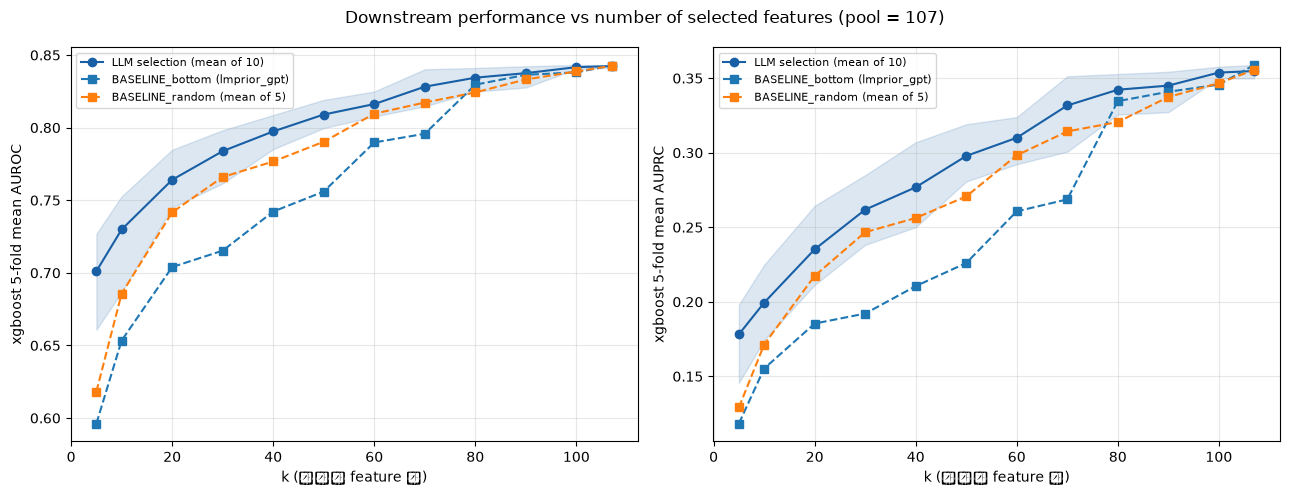

k,5,10,20,30,40,50,60,70,80,90,100,107
family2,,,,,,,,,,,,
BASELINE_bottom (lmprior_gpt),0.5962,0.6534,0.7040,0.7153,0.7422,0.7560,0.7898,0.7958,0.8296,0.8364,0.8381,0.8428
BASELINE_random (mean of 5),0.6182,0.6857,0.7417,0.7660,0.7767,0.7903,0.8096,0.8173,0.8243,0.8332,0.8387,0.8426
LLM selection (mean of 10),0.7011,0.7299,0.7641,0.7838,0.7974,0.8090,0.8162,0.8282,0.8344,0.8376,0.8417,0.8424


In [11]:
# =============================================================================
# 5-3. Figure — k sweep 시각화
# =============================================================================
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True)
for ax, metric, ylab in [(axes[0], 'auc', f'{SWEEP_MODEL} {N_SPLITS}-fold mean AUROC'),
                         (axes[1], 'ap',  f'{SWEEP_MODEL} {N_SPLITS}-fold mean AUPRC')]:
    llm = (sweep_df[sweep_df.family == 'llm']
           .groupby('k')[metric].agg(['mean', 'min', 'max']).reset_index())
    ax.plot(llm.k, llm['mean'], marker='o', label='LLM selection (mean of 10)', color='#185FA5')
    ax.fill_between(llm.k, llm['min'], llm['max'], alpha=0.15, color='#185FA5')
    for sel, g in sweep_df[sweep_df.family == 'baseline'].groupby('selection'):
        g = g.sort_values('k')
        ax.plot(g.k, g[metric], marker='s', linestyle='--', label=sel)
    ax.set_xlabel('k (선택된 feature 수)'); ax.set_ylabel(ylab)
    ax.grid(alpha=0.3); ax.legend(fontsize=8)
fig.suptitle(f'Downstream performance vs number of selected features (pool = {N_POOL})')
fig.tight_layout()
fig.savefig(os.path.join(OUT, 'Figure4_k_sweep.png'), dpi=200, bbox_inches='tight')
plt.show()

summary = (sweep_df.assign(family2=lambda d: np.where(d.family == 'baseline', d.selection,
                                                      'LLM selection (mean of 10)'))
                   .groupby(['family2', 'k'])[['auc', 'ap']].mean().round(4).reset_index())
display(summary.pivot(index='family2', columns='k', values='auc'))
summary.to_csv(os.path.join(OUT, 'Downstream_ksweep_summary.csv'), index=False, encoding='utf-8-sig')

## §6. 모델 간 비교

In [12]:
# =============================================================================
# 6. 모델 간 비교 — 각 방법 top-30 을 4개 모델로 평가
# =============================================================================
TOP_K = 30
_f_model = os.path.join(OUT, 'Downstream_model_comparison.csv')

if USE_CACHE and os.path.exists(_f_model):
    model_df = pd.read_csv(_f_model)
    print(f'[cache] {os.path.basename(_f_model)} 재사용')
else:
    rows = []
    for name in sorted(METHOD_VECTORS):
        cols, unavail = features_to_columns(top_k(name, TOP_K))
        assert not unavail, f'{name}: 매핑 실패 {unavail}'
        for mname in MODEL_NAMES:
            au, ap = cv_scores(cols, mname)
            rows.append({'method': name, 'model': mname, 'k': TOP_K, 'n_cols': len(cols),
                         'auc': round(au.mean(), 4), 'auc_std': round(au.std(ddof=0), 4),
                         'ap': round(ap.mean(), 4)})
        print(f'  {name:18} 완료', flush=True)
    model_df = pd.DataFrame(rows)
    model_df.to_csv(_f_model, index=False, encoding='utf-8-sig')

display(model_df.pivot(index='method', columns='model', values='auc').round(4))
print('\n방법별 평균 AUROC (모델 4종 평균)')
display(model_df.groupby('method').auc.mean().round(4).sort_values(ascending=False).to_frame())

C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2290562890.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = X.select_dtypes(include=['object', 'category']).columns.tolist()
C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2290562890.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/

  lmprior_gpt        완료


C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2290562890.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = X.select_dtypes(include=['object', 'category']).columns.tolist()
C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2290562890.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/

  rank_claude        완료


C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2290562890.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = X.select_dtypes(include=['object', 'category']).columns.tolist()
C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2290562890.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/

...

C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2290562890.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = X.select_dtypes(include=['object', 'category']).columns.tolist()
C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2290562890.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/

  score_gemini       완료
  score_gpt          완료
  seq_claude         완료
  seq_gemini         완료
  seq_gpt            완료


model,lightgbm,logistic_regression,random_forest,xgboost
method,,,,
lmprior_gpt,0.7713,0.7494,0.7685,0.7735
rank_claude,0.7904,0.7588,0.7815,0.7911
rank_gemini,0.7940,0.7615,0.7857,0.7929
rank_gpt,0.7951,0.7563,0.7909,0.7982
score_claude,0.7727,0.7486,0.7680,0.7728
score_gemini,0.7878,0.7630,0.7863,0.7900
score_gpt,0.7757,0.7517,0.7686,0.7756
seq_claude,0.7891,0.7405,0.7881,0.7917
seq_gemini,0.7853,0.7417,0.7849,0.7908



방법별 평균 AUROC (모델 4종 평균)


,auc
method,
rank_gpt,0.7851
rank_gemini,0.7835
score_gemini,0.7818
rank_claude,0.7804
seq_claude,0.7774
seq_gemini,0.7757
score_gpt,0.7679
lmprior_gpt,0.7657
score_claude,0.7655


## §7. 민감도 분석 — 결측률 기준 제외

주 분석은 107개 전체를 쓴다. 결측률로 미리 거르면 LLM 선택을 평가하기 전에 다른 기준의 변수 선택이 먼저 개입해 비교가 오염되기 때문이다. 다만 심사 대응을 위해 제외 버전도 함께 보고한다.

In [13]:
# =============================================================================
# 7. 민감도 분석 — 결측률 기준으로 변수를 제외하면 성능이 어떻게 되나
#   주 분석은 107개 전체를 사용한다. 결측률로 미리 거르면 LLM 선택을 평가하기 전에
#   다른 기준의 변수 선택이 먼저 개입해 비교가 오염되기 때문이다.
#   다만 심사 대응을 위해 제외 버전도 함께 보고한다.
# =============================================================================
_f_sens = os.path.join(OUT, 'Downstream_missing_sensitivity.csv')

if USE_CACHE and os.path.exists(_f_sens):
    sens_df = pd.read_csv(_f_sens)
    print(f'[cache] {os.path.basename(_f_sens)} 재사용')
else:
    rows = []
    for th in [100, 70, 50, 30]:
        keep = miss_df[miss_df.missing_pct < th]['feature'].tolist() if th < 100 else list(POOL)
        cols, _ = features_to_columns(keep)
        au, ap = cv_scores(cols, 'xgboost')
        rows.append({'threshold': f'결측 < {th}%' if th < 100 else '전체 (주 분석)',
                     'n_features': len(keep), 'n_cols': len(cols),
                     'auc': round(au.mean(), 4), 'auc_std': round(au.std(ddof=0), 4),
                     'ap': round(ap.mean(), 4)})
        print(f'  결측 <{th}% : {len(keep):3d}개 feature, AUROC {au.mean():.4f}', flush=True)
    sens_df = pd.DataFrame(rows)
    sens_df.to_csv(_f_sens, index=False, encoding='utf-8-sig')

display(sens_df)
print('\n산출물:')
for f in sorted(os.listdir(OUT)):
    print('  -', f)

C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2290562890.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = X.select_dtypes(include=['object', 'category']).columns.tolist()


  결측 <100% : 107개 feature, AUROC 0.8430


C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2290562890.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = X.select_dtypes(include=['object', 'category']).columns.tolist()


  결측 <70% : 102개 feature, AUROC 0.8430


C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2290562890.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = X.select_dtypes(include=['object', 'category']).columns.tolist()


  결측 <50% :  91개 feature, AUROC 0.8431


C:\Users\gykwa\AppData\Local\Temp\ipykernel_6068\2290562890.py:30: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat = X.select_dtypes(include=['object', 'category']).columns.tolist()


  결측 <30% :  85개 feature, AUROC 0.8416


,threshold,n_features,n_cols,auc,auc_std,ap
0,전체 (주 분석),107,151,0.8430,0.0080,0.3581
1,결측 < 70%,102,146,0.8430,0.0069,0.3531
2,결측 < 50%,91,127,0.8431,0.0069,0.3521
3,결측 < 30%,85,115,0.8416,0.0053,0.3543



산출물:
  - Downstream_baselines.csv
  - Downstream_ksweep.csv
  - Downstream_ksweep_summary.csv
  - Downstream_missing_sensitivity.csv
  - Downstream_model_comparison.csv
  - Figure4_k_sweep.png
  - feature_mapping_audit.csv
  - missingness_diagnostics.csv
